# Transformer language model

Train a Transformer on TinyStories, plot the losses, evaluate perplexity, and generate stories.

## 1. Setup

Run the clone command once, then open the project folder.

In [14]:
!git clone https://github.com/syeddaniyalg/cs5326-pa1.git /kaggle/working/cs5326-pa1
%cd /kaggle/working/cs5326-pa1

fatal: destination path '/kaggle/working/cs5326-pa1' already exists and is not an empty directory.
/kaggle/working/cs5326-pa1


In [15]:
import os
import json
import math

import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from tokenizers import Tokenizer
from huggingface_hub import hf_hub_download

from src.data import load_token_array, get_batch
from src.model import TransformerLM
from src.generate import generate
from src.optim import AdamW, cross_entropy, get_lr_cosine_schedule, gradient_clipping

device = 'cuda'
print(torch.cuda.get_device_name())

seed = 42
torch.manual_seed(seed)

vocab_size = 8192
context_length = 256
d_model = 512
num_layers = 4
n_q_heads = 16
n_kv_heads = 4
d_ff = 1344
rope_theta = 10000.0

batch_size = 32
accumulation_steps = 8
num_steps = 10000
learning_rate_max = 3e-4
learning_rate_min = 3e-5
warmup_steps = 200
cosine_steps = 9999
max_grad_norm = 1.0
eval_interval = 500
checkpoint_interval = 500

data_dir = '/kaggle/working/tinystories'
checkpoint_path = '/kaggle/working/checkpoint.pt'
os.makedirs(data_dir, exist_ok=True)
os.makedirs('report_assets', exist_ok=True)

Tesla T4


## 2. Dataset and tokenizer

Load the TinyStories text and tokenizer.

In [16]:
train_text = '/kaggle/input/datasets/thesyeddaniyal/tinystories-v2-gpt4-official/TinyStoriesV2-GPT4-train.txt'
val_text = '/kaggle/input/datasets/thesyeddaniyal/tinystories-v2-gpt4-official/TinyStoriesV2-GPT4-valid.txt'

tokenizer_path = hf_hub_download(repo_id='alooboii/pa1-tinystories', repo_type='dataset', filename='tokenizer/tokenizer.json')
tokenizer = Tokenizer.from_file(tokenizer_path)
eot_id = tokenizer.token_to_id('<|endoftext|>')

train_path = data_dir + '/train.bin'
val_path = data_dir + '/validation.bin'

## 3. Prepare the data

Read the text in chunks and save token IDs. A temporary file is renamed after tokenization finishes. Run this cell once to prepare both files.

In [17]:
def write_stories(stories, output):
    encodings = tokenizer.encode_batch(stories, add_special_tokens=False)
    for encoding in encodings:
        tokens = np.array(encoding.ids + [eot_id], dtype='<u2')
        output.write(tokens.tobytes())

def tokenize_file(text_path, output_path):
    buffer = ''
    stories = []

    with open(text_path, 'r', encoding='utf-8', newline='') as source, open(output_path + '.tmp', 'wb') as output:
        with tqdm(total=os.path.getsize(text_path), unit='B', unit_scale=True, desc='Tokenizing') as progress:
            while True:
                chunk = source.read(8000000)
                if not chunk:
                    break

                buffer += chunk
                parts = buffer.split('<|endoftext|>')
                buffer = parts.pop()

                for story in parts:
                    if story.strip():
                        stories.append(story)

                    if len(stories) == 4096:
                        write_stories(stories, output)
                        stories = []

                progress.update(len(chunk.encode('utf-8')))

            if buffer.strip():
                stories.append(buffer)
            if stories:
                write_stories(stories, output)

    os.replace(output_path + '.tmp', output_path)

tokenize_file(train_text, train_path)
tokenize_file(val_text, val_path)

Tokenizing: 100%|██████████| 2.23G/2.23G [09:56<00:00, 3.74MB/s]
Tokenizing: 100%|██████████| 22.5M/22.5M [00:06<00:00, 3.75MB/s]


In [18]:
train_tokens = load_token_array(train_path)
val_tokens = load_token_array(val_path)

print('Training tokens:', len(train_tokens))
print('Validation tokens:', len(val_tokens))

Training tokens: 544442942
Validation tokens: 5498516


## 4. Model and optimizer

Create the model and optimizer. Training uses mixed precision and gradient accumulation.

In [19]:
model = TransformerLM(vocab_size, context_length, d_model, num_layers, n_q_heads, n_kv_heads, d_ff, rope_theta, device=device)
optimizer = AdamW(model.parameters(), lr=learning_rate_max, betas=(0.9, 0.95), eps=1e-8, weight_decay=0.1)
scaler = torch.amp.GradScaler('cuda')

train_generator = torch.Generator().manual_seed(seed)
val_generator = torch.Generator().manual_seed(seed + 1)
next_step = 0
history = []

print('Parameters:', sum(p.numel() for p in model.parameters()))

Parameters: 19272192


### Resume training

Leave `resume = False` for a new run. Set it to `True` to load a saved checkpoint.

In [24]:
resume = True

if resume:
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    train_generator.set_state(checkpoint['train_generator'])
    val_generator.set_state(checkpoint['val_generator'])
    next_step = checkpoint['next_step']
    history = checkpoint.get('history', [])
    if 'scaler' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler'])
    del checkpoint
    print('Resuming at update:', next_step)

Resuming at update: 2500


## 5. Training

Show training metrics after each update. Evaluate and save a checkpoint every 500 updates.

In [25]:
def evaluate(model, tokens, generator, batches, size=16):
    was_training = model.training
    model.eval()
    total_loss = 0.0

    with torch.inference_mode():
        for _ in range(batches):
            x, y = get_batch(tokens, size, context_length, device, generator)
            with torch.autocast('cuda', dtype=torch.float16):
                logits = model(x)
            total_loss += cross_entropy(logits.float(), y).item()

    model.train(was_training)
    return total_loss / batches

def save_training():
    checkpoint = {
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scaler': scaler.state_dict(),
        'train_generator': train_generator.get_state(),
        'val_generator': val_generator.get_state(),
        'next_step': next_step,
        'history': history
    }
    torch.save(checkpoint, checkpoint_path + '.tmp')
    os.replace(checkpoint_path + '.tmp', checkpoint_path)

In [26]:
with tqdm(total=num_steps, initial=next_step, desc='Training', unit='update') as progress:
    while next_step < num_steps:
        model.train()
        lr = get_lr_cosine_schedule(next_step, learning_rate_max, learning_rate_min, warmup_steps, cosine_steps)

        for group in optimizer.param_groups:
            group['lr'] = lr

        optimizer.zero_grad(set_to_none=True)
        train_loss = torch.zeros((), device=device)

        for _ in range(accumulation_steps):
            x, y = get_batch(train_tokens, batch_size, context_length, device, train_generator)

            with torch.autocast('cuda', dtype=torch.float16):
                logits = model(x)

            loss = cross_entropy(logits.float(), y)
            scaler.scale(loss / accumulation_steps).backward()
            train_loss += loss.detach()

        scaler.unscale_(optimizer)
        grad_norm = gradient_clipping(model.parameters(), max_grad_norm)
        old_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()

        # A smaller scale means the optimizer skipped this update.
        if scaler.get_scale() < old_scale:
            continue

        next_step += 1
        train_loss = (train_loss / accumulation_steps).item()
        row = {'step': next_step, 'train_loss': train_loss, 'lr': lr, 'grad_norm': grad_norm}
        metrics = {'loss': f'{train_loss:.3f}', 'lr': f'{lr:.2e}', 'grad': f'{grad_norm:.2f}'}

        if next_step % eval_interval == 0 or next_step == num_steps:
            val_loss = evaluate(model, val_tokens, val_generator, 20)
            row['validation_loss'] = val_loss
            metrics['val'] = f'{val_loss:.3f}'
            tqdm.write(f'Update {next_step}: validation loss = {val_loss:.4f}')

        history.append(row)
        progress.update(1)
        progress.set_postfix(metrics, refresh=True)

        if next_step % checkpoint_interval == 0 or next_step == num_steps:
            save_training()

Training:  30%|███       | 3000/10000 [15:29<4:03:37,  2.09s/update, loss=1.655, lr=2.49e-04, grad=0.37, val=1.692]

Update 3000: validation loss = 1.6920


Training:  35%|███▌      | 3500/10000 [30:59<3:46:12,  2.09s/update, loss=1.675, lr=2.31e-04, grad=0.36, val=1.646]

Update 3500: validation loss = 1.6461


Training:  40%|████      | 4000/10000 [46:30<3:28:56,  2.09s/update, loss=1.609, lr=2.12e-04, grad=0.37, val=1.624]

...

Training:  95%|█████████▌| 9500/10000 [3:36:59<17:26,  2.09s/update, loss=1.487, lr=3.17e-05, grad=0.36, val=1.480]

Update 9500: validation loss = 1.4797


Training: 100%|██████████| 10000/10000 [3:52:30<00:00,  2.09s/update, loss=1.457, lr=3.00e-05, grad=0.36, val=1.484]

Update 10000: validation loss = 1.4842


Training: 100%|██████████| 10000/10000 [3:52:30<00:00,  1.86s/update, loss=1.457, lr=3.00e-05, grad=0.36, val=1.484]


## 6. Training curves

Save the loss history and plot training and validation loss.

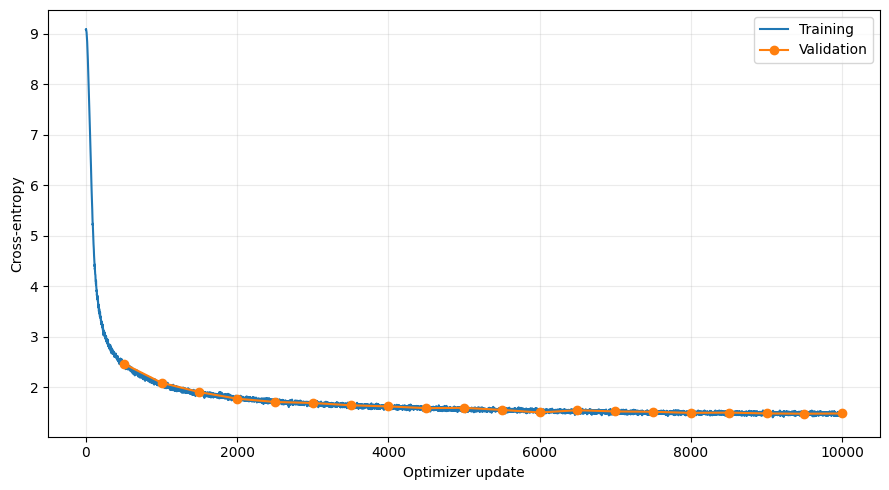

In [27]:
with open('/kaggle/working/training_history.json', 'w') as file:
    json.dump(history, file, indent=2)

steps = [row['step'] for row in history]
train_losses = [row['train_loss'] for row in history]
validation = [row for row in history if 'validation_loss' in row]

plt.figure(figsize=(9,5))
plt.plot(steps, train_losses, label='Training')
plt.plot([row['step'] for row in validation], [row['validation_loss'] for row in validation], 'o-', label='Validation')
plt.xlabel('Optimizer update')
plt.ylabel('Cross-entropy')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('report_assets/training_loss.png', dpi=160)
plt.show()

## 7. Final validation

Evaluate 100 batches of 16 sequences, each 256 tokens long, using a new generator seeded with 42. Perplexity is the exponential of mean cross-entropy.

In [28]:
final_generator = torch.Generator().manual_seed(42)
final_loss = evaluate(model, val_tokens, final_generator, 100, size=16)
perplexity = math.exp(final_loss)

print(f'Validation cross-entropy: {final_loss:.6f}')
print(f'Validation perplexity: {perplexity:.6f}')

metrics = {'cross_entropy': final_loss, 'perplexity': perplexity}
with open('/kaggle/working/final_metrics.json', 'w') as file:
    json.dump(metrics, file, indent=2)

Validation cross-entropy: 1.482880
Validation perplexity: 4.405615


## 8. Text generation

Compare stories generated with different temperatures and top-p values.

In [31]:
def sample_text(prompt, temperature, top_p, seed=123):
    ids = tokenizer.encode(prompt, add_special_tokens=False).ids
    ids = torch.tensor(ids, dtype=torch.long, device=device)
    generator = torch.Generator(device=device).manual_seed(seed)
    output = generate(model, ids, 160, context_length, temperature=temperature, top_p=top_p, eot_token_id=eot_id, generator=generator)
    return tokenizer.decode(output.tolist(), skip_special_tokens=False)

prompts = ['Once upon a time', 'Mia found a shiny red box in the park.']
settings = [(0.1,0.9), (0.3,0.9), (0.5,0.9), (0.7,0.9), (1.0,0.9), (1.2,0.9), (1.5,0.9), (2.0,0.9), (1.0,0.7), (1.0,1.0)]
samples = []

for prompt in prompts:
    for temperature, top_p in settings:
        text = sample_text(prompt, temperature, top_p)
        samples.append({'prompt': prompt, 'temperature': temperature, 'top_p': top_p, 'text': text})

        print(f'\nTemperature: {temperature}, top-p: {top_p}')
        print(text)

with open('/kaggle/working/generations.json', 'w') as file:
    json.dump(samples, file, indent=2)


Temperature: 0.1, top-p: 0.9
Once upon a time, there was a little girl named Lily. She had a big, red ball that she loved to play with. One day, she went to the park with her mom. Lily was very happy.
At the park, Lily saw a big tree. She wanted to climb it. She put her ball down and started to climb. But, she was not careful. She fell down and hurt her knee. Lily cried and her mom came to help her.
Lily's mom took her to the doctor. The doctor said, "Don't worry, Lily. I will help you." The doctor took a deep breath and let Lily climb on his back. Lily was so happy to be safe. She hugged her mom and said, "Thank you, doctor!"
<|endoftext|>

Temperature: 0.3, top-p: 0.9
Once upon a time, there was a little boy named Tim. Tim had a big, red ball. He loved to play with his ball every day. One day, Tim saw a big, red ball in the park. He wanted to play with it.
Tim asked his mom, "Can I play with the big, red ball?" His mom said, "Yes, but be careful. It is very big and heavy." Tim was v

## 9. Save the model

Save the model weights on CPU in FP16.

In [30]:
state = {}
for name, tensor in model.state_dict().items():
    tensor = tensor.detach().cpu()
    if tensor.is_floating_point():
        tensor = tensor.half()
    state[name] = tensor

assert sum(t.numel() for t in state.values()) == 19272192
assert all(torch.isfinite(t).all() for t in state.values())

torch.save(state, 'final_model.pt')
print('Saved: /kaggle/working/cs5326-pa1/final_model.pt')

Saved: /kaggle/working/cs5326-pa1/final_model.pt
